In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder




# Load and Explore the Dataset


### 1. Data Loading & Memory Optimization

Applied **downcasting** (`float64` → `float32`, `int64` → `int32`) to reduce memory usage by ~50%, enabling faster processing without affecting data quality.

In [2]:
# Set up my data path
path = r'../Data/raw'
all_files = glob.glob(os.path.join(path, "*.csv"))

print(f"Found {len(all_files)} files. Processing...")

df_list = []
for file in all_files:
    print(f"Reading and compressing: {os.path.basename(file)}")
    temp_df = pd.read_csv(file)
    
    temp_df.columns = temp_df.columns.str.strip()
    
    for col in temp_df.columns:
        if temp_df[col].dtype == 'float64':
            temp_df[col] = temp_df[col].astype('float32')
        elif temp_df[col].dtype == 'int64':
            temp_df[col] = temp_df[col].astype('int32')
            
    df_list.append(temp_df)

# Merge everything into my main df
print("\nMerging files...")
df = pd.concat(df_list, axis=0, ignore_index=True)

print("\n --- Merging and cleaning successful! --- ")
print(f"My final dataset shape: {df.shape[0]:,} rows, {df.shape[1]} columns.")
print("\nMy final label distribution:")
print(df['Label'].value_counts())

Found 8 files. Processing...
Reading and compressing: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Reading and compressing: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Reading and compressing: Friday-WorkingHours-Morning.pcap_ISCX.csv
Reading and compressing: Monday-WorkingHours.pcap_ISCX.csv
Reading and compressing: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Reading and compressing: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Reading and compressing: Tuesday-WorkingHours.pcap_ISCX.csv
Reading and compressing: Wednesday-workingHours.pcap_ISCX.csv

Merging files...

 --- Merging and cleaning successful! --- 
My final dataset shape: 2,830,743 rows, 79 columns.

My final label distribution:
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                 

### Explore Data

In [3]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [4]:
df.sample(5)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
2577901,53,47009,1,1,64,117,64,64,64.00000,0.00000,...,20,0.0,0.0000,0,0,0.0,0.000000,0,0,BENIGN
1435075,8193,3,2,0,4,0,2,2,2.00000,0.00000,...,24,0.0,0.0000,0,0,0.0,0.000000,0,0,BENIGN
303024,443,118088819,13,12,578,4627,192,0,44.46154,65.86554,...,32,169228.5,130444.9375,261467,76990,58900000.0,92411.789062,58900000,58800000,BENIGN
2453950,80,5,3,0,0,0,0,0,0.00000,0.00000,...,32,0.0,0.0000,0,0,0.0,0.000000,0,0,DoS Hulk
2626926,53,76006,2,2,80,278,40,40,40.00000,0.00000,...,20,0.0,0.0000,0,0,0.0,0.000000,0,0,BENIGN


In [5]:
df.tail()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
2830738,53,32215,4,2,112,152,28,28,28.0,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2830739,53,324,2,2,84,362,42,42,42.0,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2830740,58030,82,2,1,31,6,31,0,15.5,21.920311,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2830741,53,1048635,6,2,192,256,32,32,32.0,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2830742,53,94939,4,2,188,226,47,47,47.0,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [6]:
df.dtypes

Destination Port                 int32
Flow Duration                    int32
Total Fwd Packets                int32
Total Backward Packets           int32
Total Length of Fwd Packets      int32
                                ...   
Idle Mean                      float32
Idle Std                       float32
Idle Max                         int32
Idle Min                         int32
Label                           object
Length: 79, dtype: object

In [7]:
df.shape

(2830743, 79)

In [8]:
df.describe()

c:\Users\COMPUMARTS\anaconda3\envs\ai_env\lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\COMPUMARTS\anaconda3\envs\ai_env\lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,...,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2830743.0,2.830743e+06,2.830743e+06,2.830743e+06
mean,8.071483e+03,1.478566e+07,9.361160e+00,1.039377e+01,5.493024e+02,1.616264e+04,2.075999e+02,1.871366e+01,5.820191e+01,6.891013e+01,...,5.418218e+00,-2.741688e+03,8.155138e+04,4.113413e+04,1.531825e+05,5.829582e+04,8316037.5,5.038439e+05,8.695752e+06,7.920031e+06
std,1.828363e+04,3.365374e+07,7.496728e+02,9.973883e+02,9.993589e+03,2.263088e+06,7.171848e+02,6.033935e+01,1.860912e+02,2.811871e+02,...,6.364257e+02,1.084989e+06,6.485999e+05,3.933815e+05,1.025825e+06,5.770923e+05,23630078.0,4.602984e+06,2.436689e+07,2.336342e+07
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,1.550000e+02,2.000000e+00,1.000000e+00,1.200000e+01,0.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,3.131600e+04,2.000000e+00,2.000000e+00,6.200000e+01,1.230000e+02,3.700000e+01,2.000000e+00,3.400000e+01,0.000000e+00,...,1.000000e+00,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.430000e+02,3.204828e+06,5.000000e+00,4.000000e+00,1.870000e+02,4.820000e+02,8.100000e+01,3.600000e+01,5.000000e+01,2.616295e+01,...,2.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,...,2.135570e+05,1.380000e+02,1.100000e+08,7.420000e+07,1.100000e+08,1.100000e+08,120000000.0,7.690000e+07,1.200000e+08,1.200000e+08


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int32  
 1   Flow Duration                int32  
 2   Total Fwd Packets            int32  
 3   Total Backward Packets       int32  
 4   Total Length of Fwd Packets  int32  
 5   Total Length of Bwd Packets  int32  
 6   Fwd Packet Length Max        int32  
 7   Fwd Packet Length Min        int32  
 8   Fwd Packet Length Mean       float32
 9   Fwd Packet Length Std        float32
 10  Bwd Packet Length Max        int32  
 11  Bwd Packet Length Min        int32  
 12  Bwd Packet Length Mean       float32
 13  Bwd Packet Length Std        float32
 14  Flow Bytes/s                 float32
 15  Flow Packets/s               float32
 16  Flow IAT Mean                float32
 17  Flow IAT Std                 float32
 18  Flow IAT Max                 int32  
 19  

In [10]:
df['Label'].unique()

array(['BENIGN', 'DDoS', 'PortScan', 'Bot', 'Infiltration',
       'Web Attack � Brute Force', 'Web Attack � XSS',
       'Web Attack � Sql Injection', 'FTP-Patator', 'SSH-Patator',
       'DoS slowloris', 'DoS Slowhttptest', 'DoS Hulk', 'DoS GoldenEye',
       'Heartbleed'], dtype=object)

In [11]:
df.select_dtypes(include='object').columns

Index(['Label'], dtype='object')

In [12]:
# Check for Infinity values in numeric columns
inf_check = {}
for col in df.select_dtypes(include=[np.number]).columns:
    inf_count = np.isinf(df[col]).sum()
    if inf_count > 0:
        inf_check[col] = inf_count

print("Columns containing Infinity values:")
for col, count in inf_check.items():
    print(f"  {col}: {count} infinite values")

if not inf_check:
    print("  No infinite values found in the dataset.")

Columns containing Infinity values:
  Flow Bytes/s: 1509 infinite values
  Flow Packets/s: 2867 infinite values


In [13]:
for col, count in inf_check.items():
    pct = (count / len(df)) * 100
    print(f"{col}: {count} values ({pct:.4f}%)")

Flow Bytes/s: 1509 values (0.0533%)
Flow Packets/s: 2867 values (0.1013%)


In [14]:
# replace inf , - inf to nan
df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [15]:
for col in ['Flow Bytes/s', 'Flow Packets/s']:
    print(f"{col}: {df[col].isnull().sum()} NaN values now")

Flow Bytes/s: 2867 NaN values now
Flow Packets/s: 2867 NaN values now


In [16]:
duplicates = df.duplicated().sum()
print(f"Number of duplicated rows: {duplicates}")

Number of duplicated rows: 330995


In [17]:
duplicates_percentage = (duplicates / len(df)) * 100
print(f"Percentage of duplicated rows: {duplicates_percentage:.2f}%")

Percentage of duplicated rows: 11.69%


In [18]:
df[df.duplicated()].head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
2109,80,77,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2257,443,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2749,443,49,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2862,443,4,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2877,443,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [19]:
df = df.drop_duplicates(keep='first')

In [20]:
print(df.isnull().sum().to_string())

Destination Port                  0
Flow Duration                     0
Total Fwd Packets                 0
Total Backward Packets            0
Total Length of Fwd Packets       0
Total Length of Bwd Packets       0
Fwd Packet Length Max             0
Fwd Packet Length Min             0
Fwd Packet Length Mean            0
Fwd Packet Length Std             0
Bwd Packet Length Max             0
Bwd Packet Length Min             0
Bwd Packet Length Mean            0
Bwd Packet Length Std             0
Flow Bytes/s                   1563
Flow Packets/s                 1563
Flow IAT Mean                     0
Flow IAT Std                      0
Flow IAT Max                      0
Flow IAT Min                      0
Fwd IAT Total                     0
Fwd IAT Mean                      0
Fwd IAT Std                       0
Fwd IAT Max                       0
Fwd IAT Min                       0
Bwd IAT Total                     0
Bwd IAT Mean                      0
Bwd IAT Std                 

In [21]:
percentage_null = (df.isnull().sum() / len(df)) * 100
percentage_null = percentage_null[percentage_null > 0]

print(percentage_null.to_string())

Flow Bytes/s      0.062526
Flow Packets/s    0.062526


In [22]:
# Deletion
df = df.dropna()

### Check Outliers

In [23]:
# IQR method
Q1 = df.quantile(0.25, numeric_only=True)
Q3 = df.quantile(0.75, numeric_only=True)
IQR = Q3 - Q1

outliers_1 = ((df.select_dtypes(include='number') < (Q1 - 1.5 * IQR)) |
            (df.select_dtypes(include='number') > (Q3 + 1.5 * IQR)))

outliers_1.sum()

Destination Port               545484
Flow Duration                  467823
Total Fwd Packets              252963
Total Backward Packets         239223
Total Length of Fwd Packets    312525
                                ...  
Active Min                     558825
Idle Mean                      567235
Idle Std                       229243
Idle Max                       567235
Idle Min                       567235
Length: 78, dtype: int64

In [24]:
outlier_rows = outliers_1.any(axis=1)

print(outlier_rows.sum())

2188649


In [25]:
df.loc[outlier_rows, "Label"].value_counts()

Label
BENIGN                        1776831
DoS Hulk                       167373
DDoS                           119567
PortScan                        90691
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

# Visualizations 

In [26]:
features = [
    'Flow Duration',
    'Total Fwd Packets',
    'Flow Bytes/s',
    'Flow Packets/s'
]

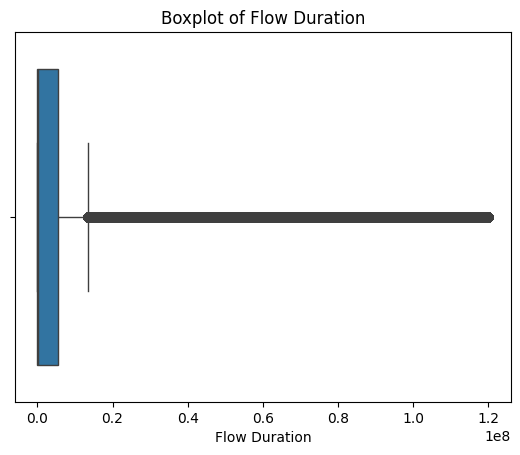

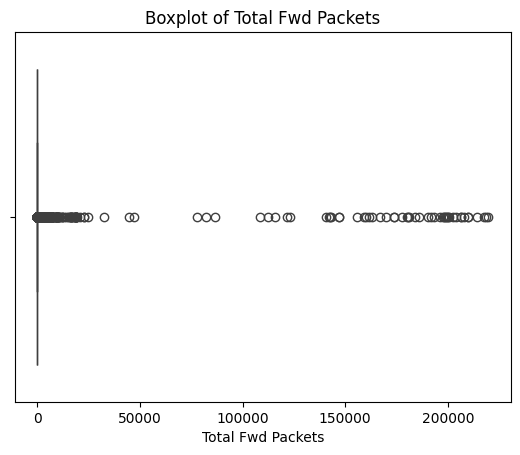

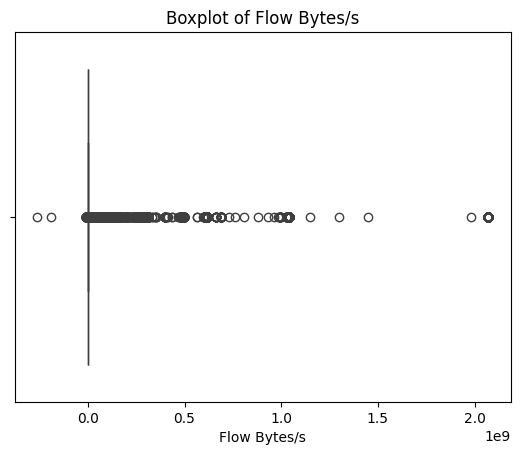

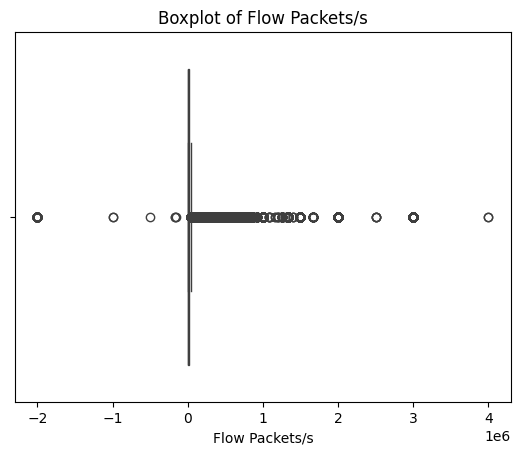

In [27]:
for feature in features:
    plt.Figure(figsize=(10, 6))
    sns.boxplot(x=df[feature], data=df)
    plt.title(f'Boxplot of {feature}')
    plt.show()

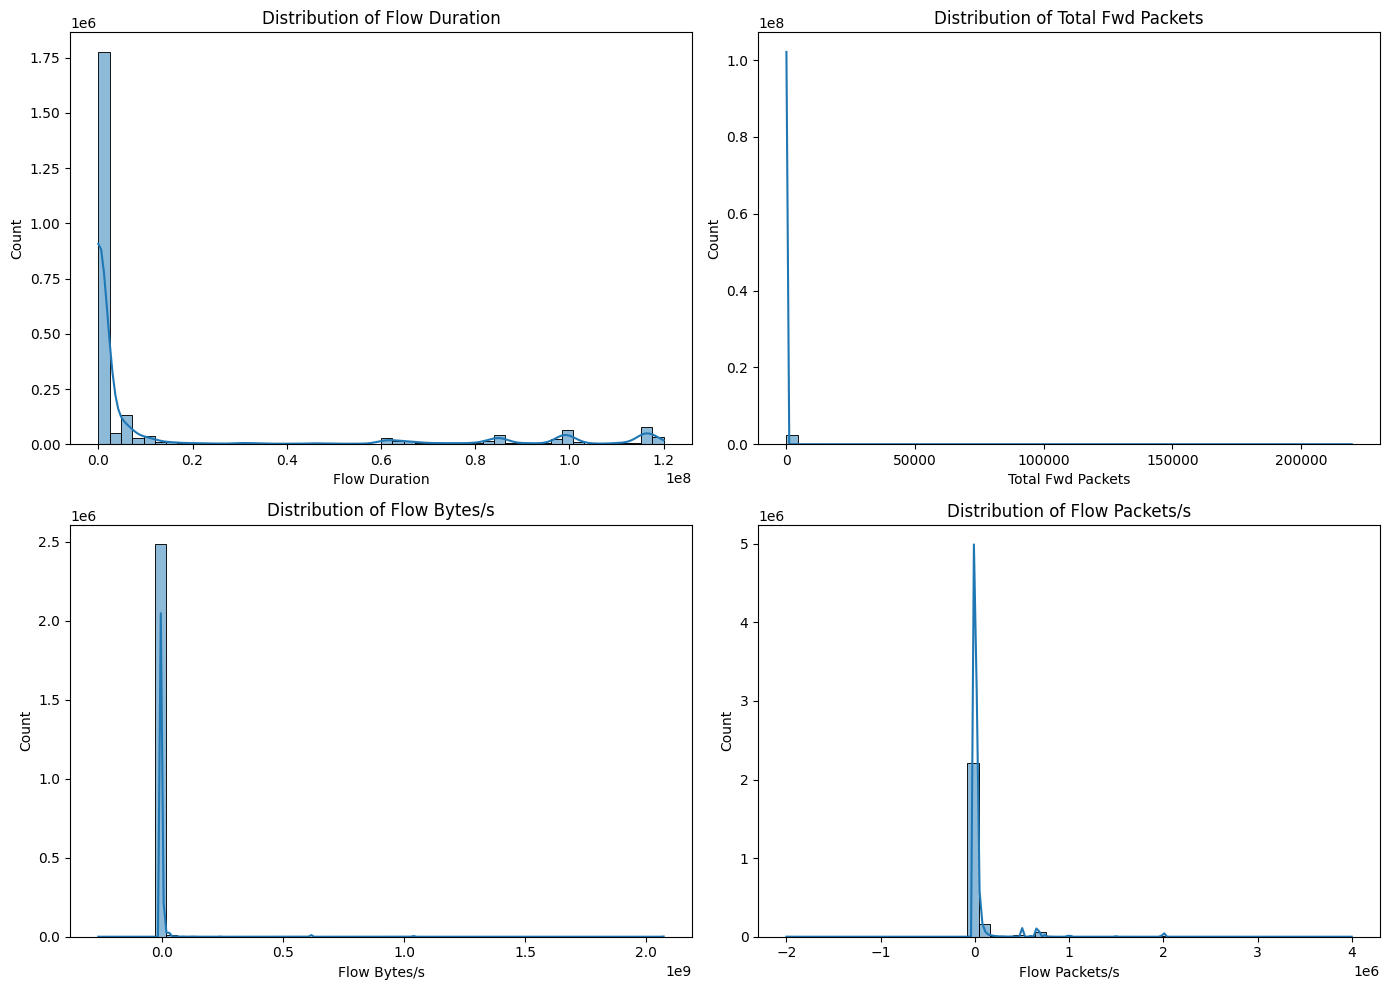

In [28]:
# Univariate - Histograms/KDE
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, col in enumerate(features):
    ax = axes[i // 2, i % 2]
    sns.histplot(df[col], kde=True, ax=ax, bins=50)
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

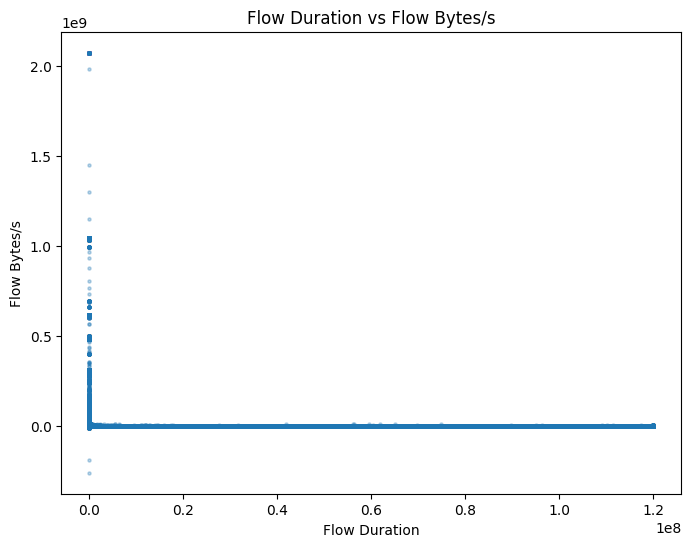

In [29]:
# Bivariate - Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(df['Flow Duration'], df['Flow Bytes/s'], alpha=0.3, s=5)
plt.xlabel('Flow Duration')
plt.ylabel('Flow Bytes/s')
plt.title('Flow Duration vs Flow Bytes/s')
plt.show()

<Figure size 1200x1000 with 0 Axes>

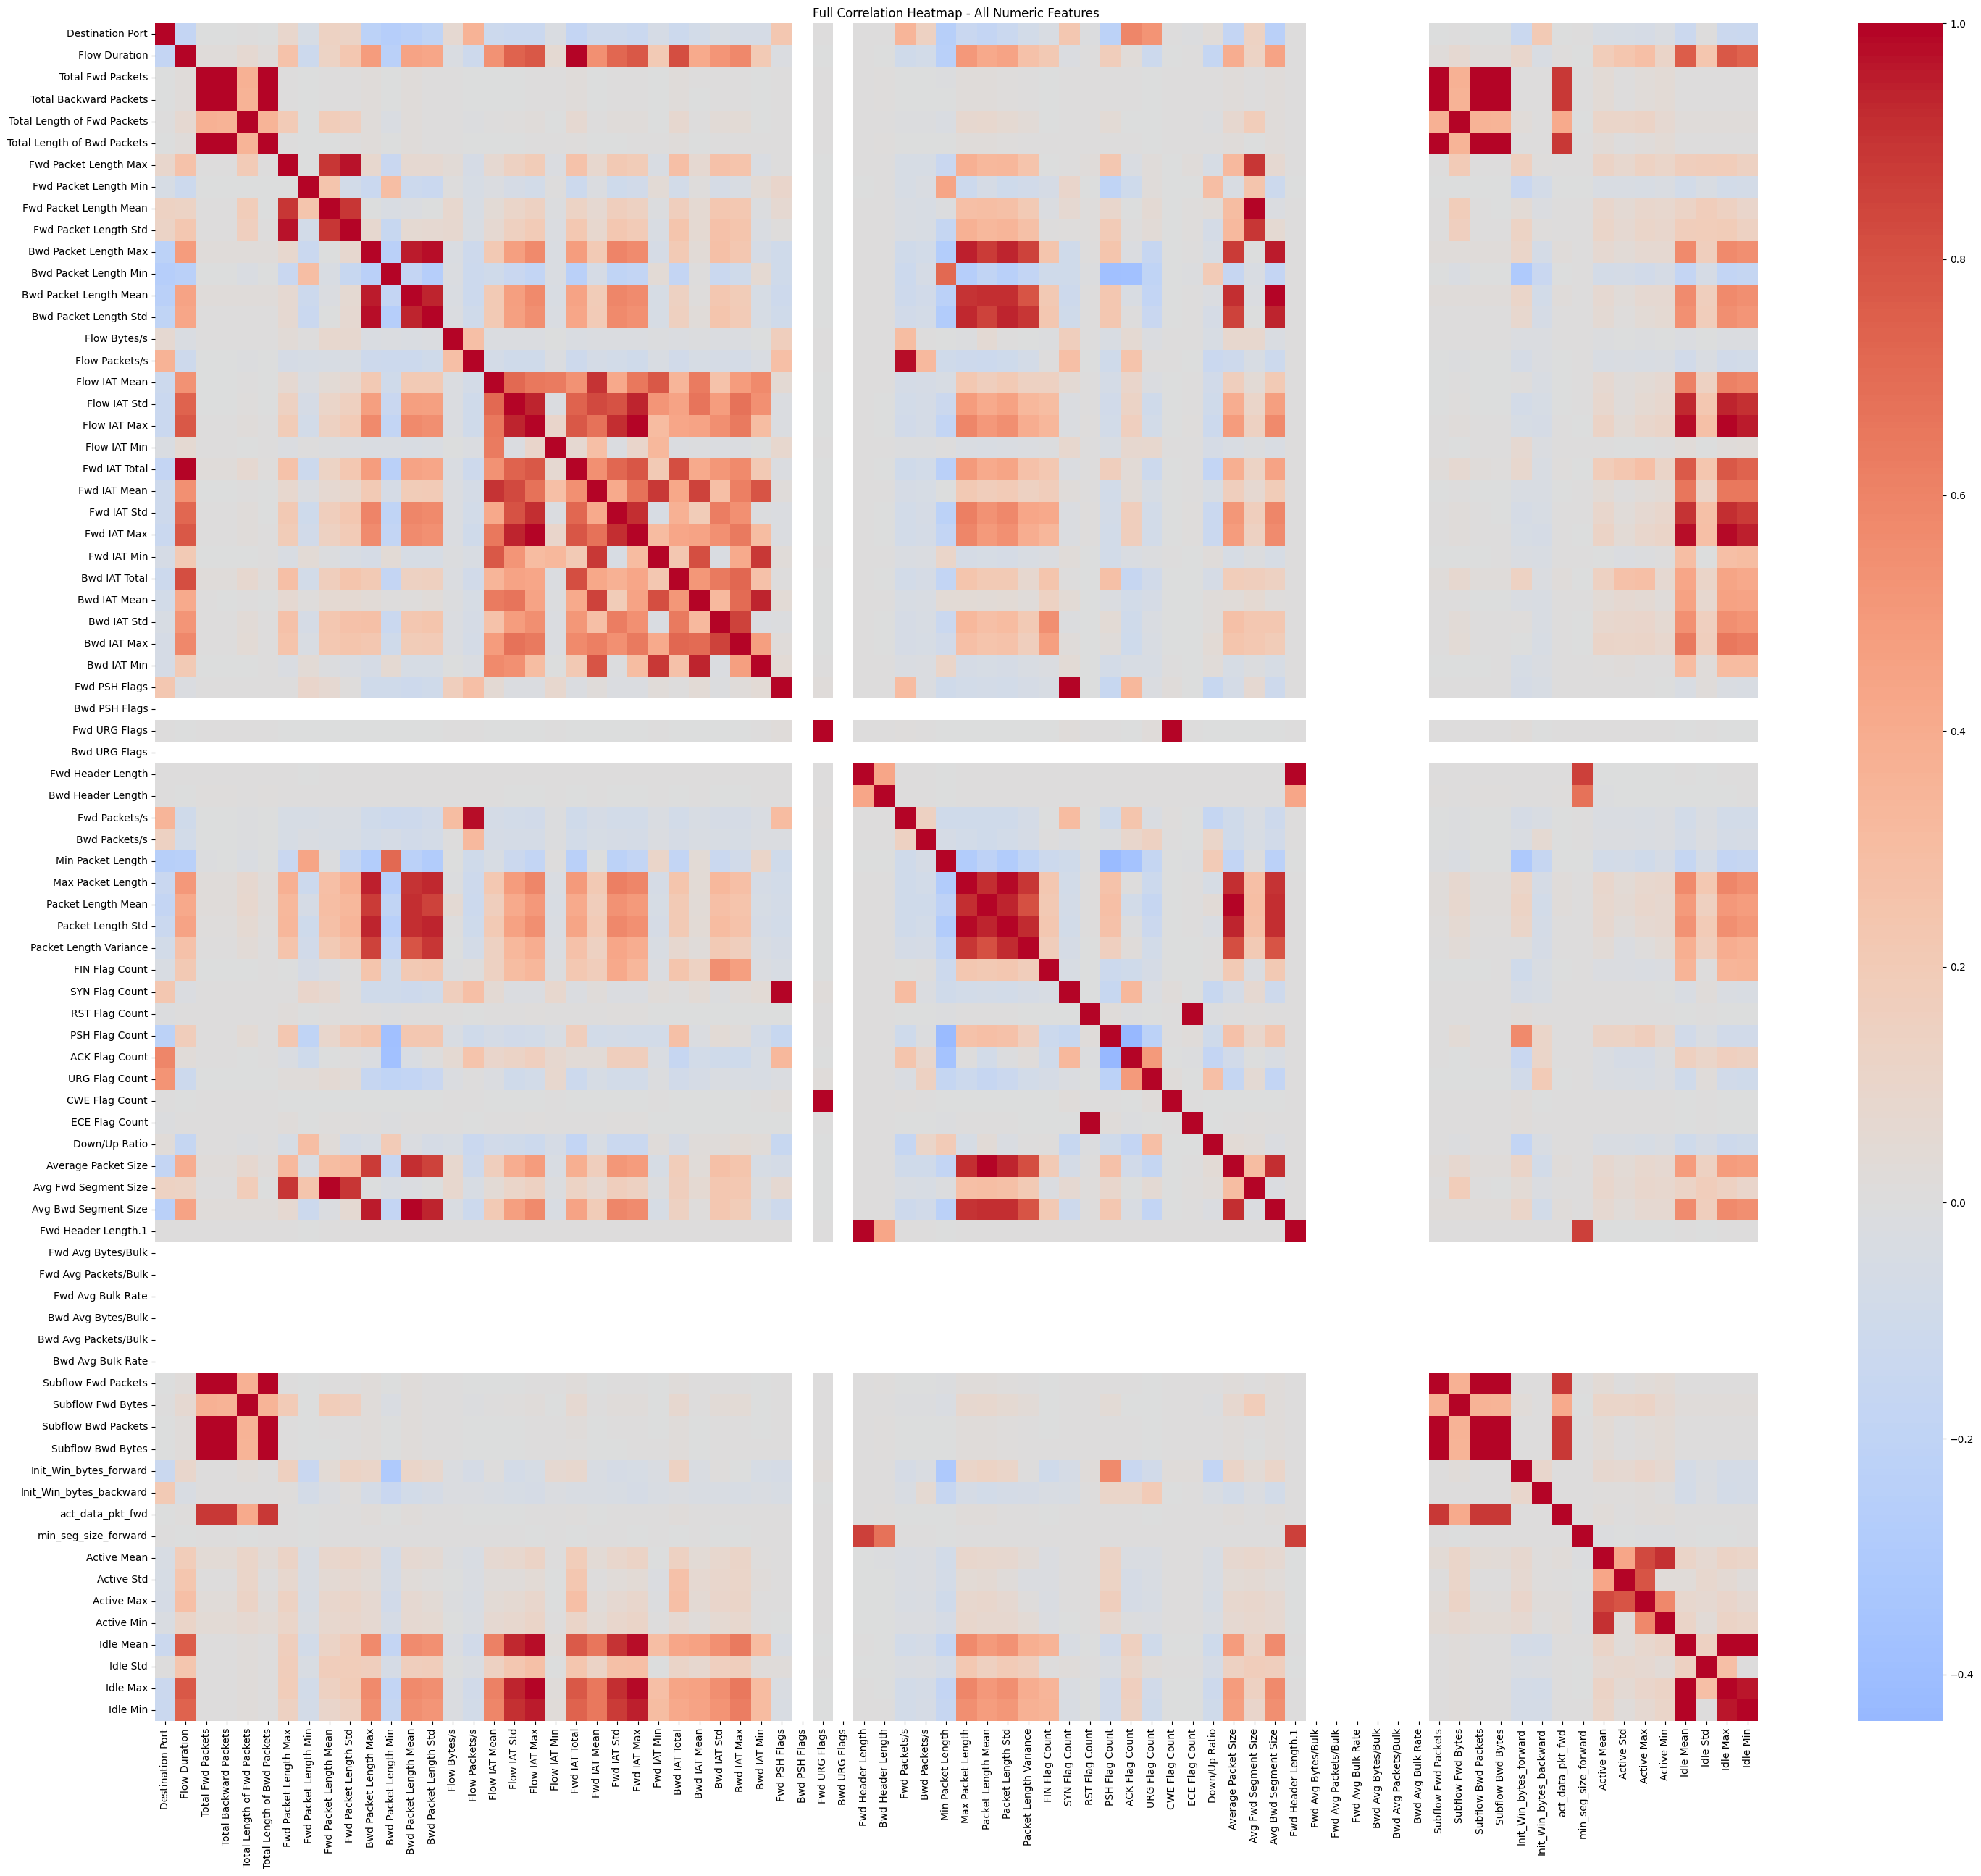

In [30]:
#  Bivariate - Correlation Heatmap
plt.figure(figsize=(12, 10))

numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(30, 26))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False) 
plt.title('Full Correlation Heatmap - All Numeric Features')
plt.tight_layout()
plt.savefig('full_heatmap.png', dpi=150) 
plt.show()

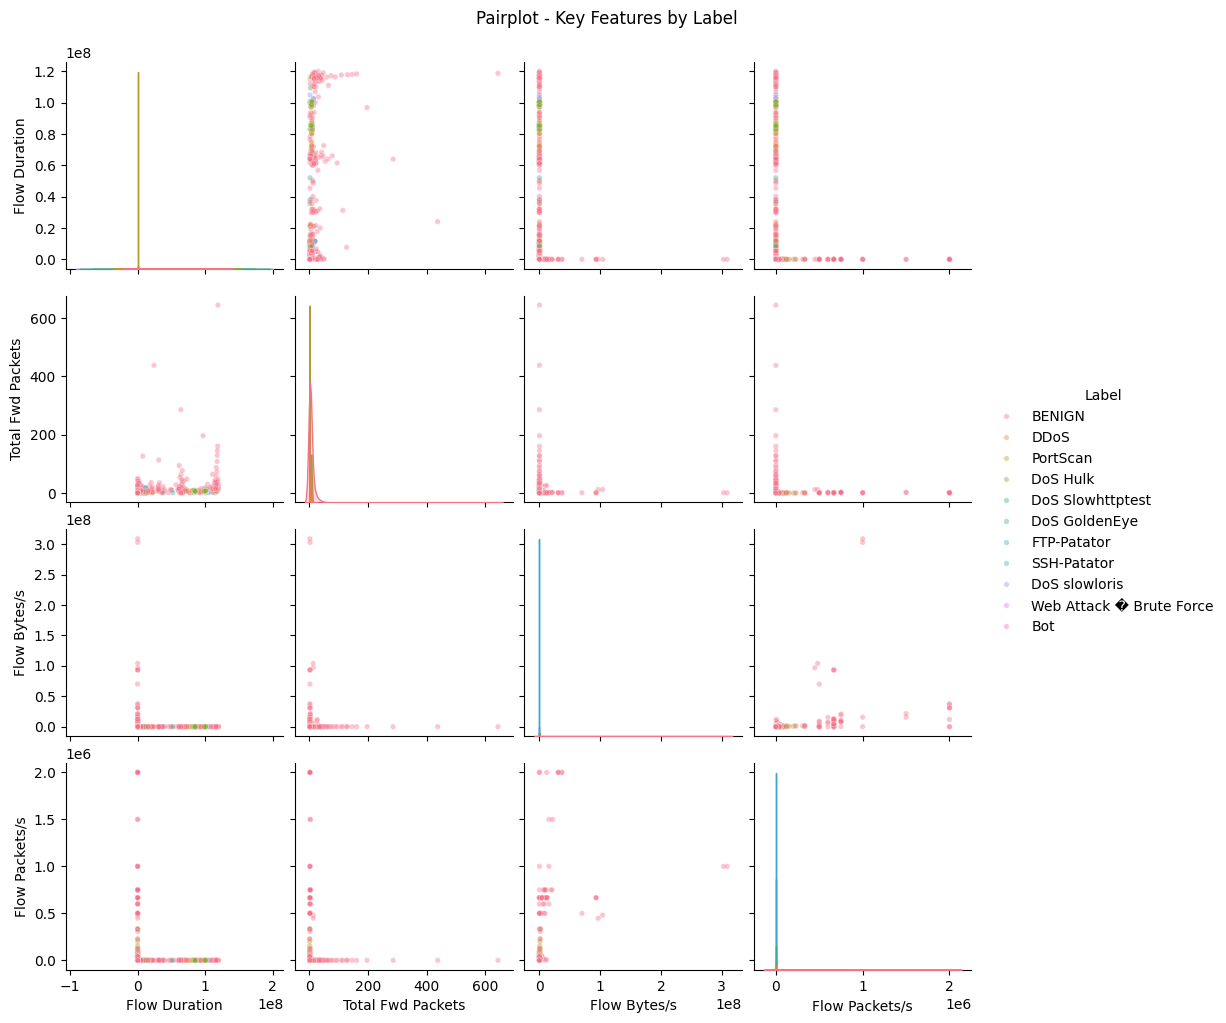

In [31]:
# Multivariate - Pairplot
sample_df = df.sample(n=2000, random_state=42)

sns.pairplot(sample_df, vars=features,
             hue='Label', diag_kind='kde', plot_kws={'alpha': 0.4, 's': 15})
plt.suptitle('Pairplot - Key Features by Label', y=1.02)
plt.show()

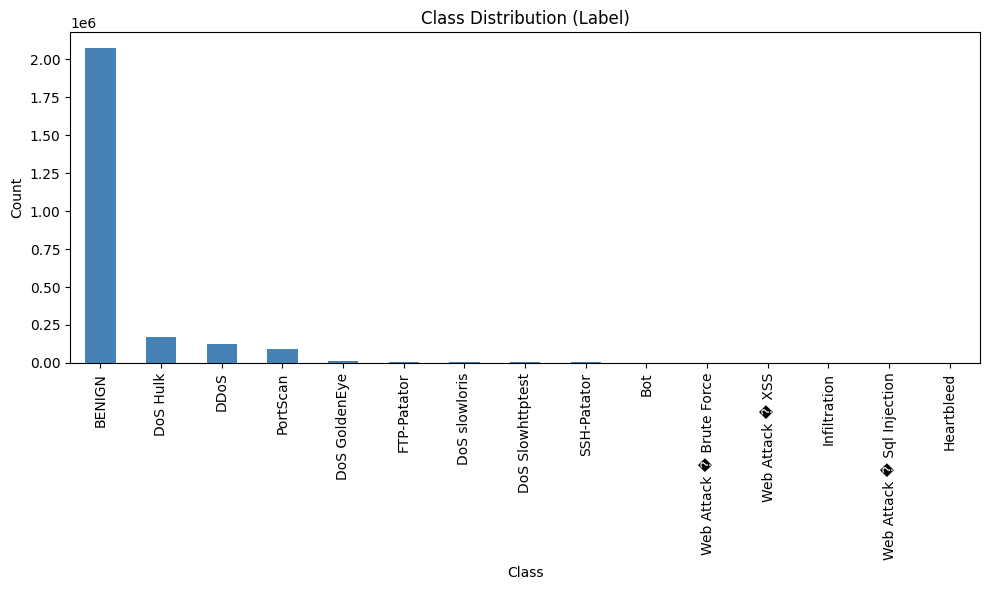

In [32]:
#  Balance - Bar chart
plt.figure(figsize=(10, 6))
df['Label'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Class Distribution (Label)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

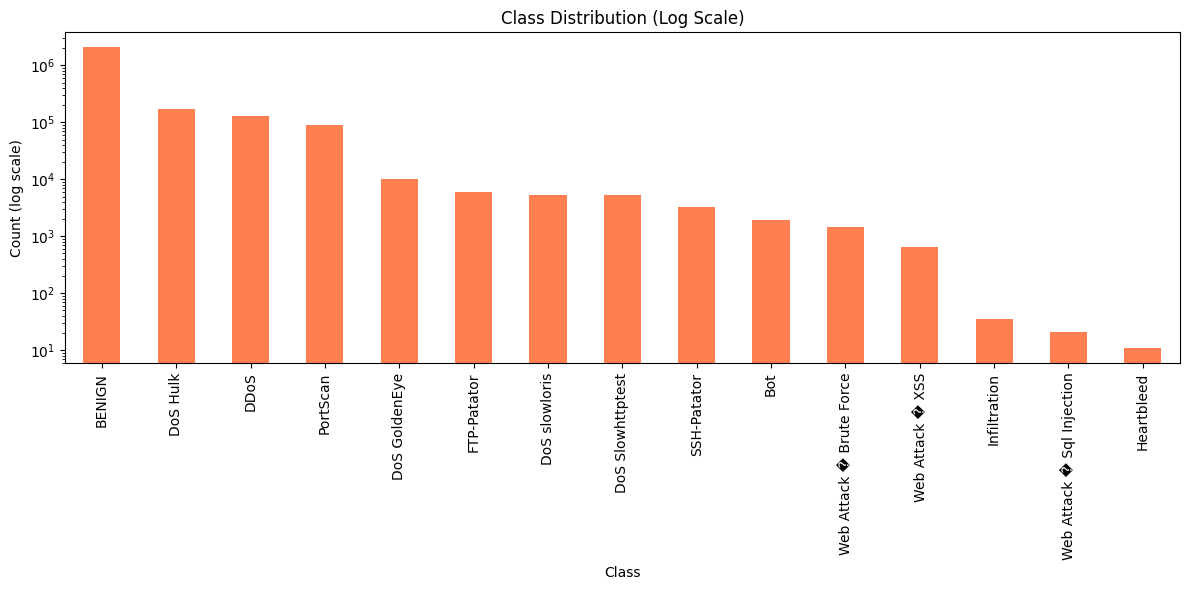

In [33]:
# log Scale - bar chart
plt.figure(figsize=(12, 6))
df['Label'].value_counts().plot(kind='bar',color='coral',logy=True)
plt.title('Class Distribution (Log Scale)')
plt.xlabel('Class')
plt.ylabel('Count (log scale)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [34]:
# find pairs of features with high correlation (e.g., above 0.8)
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr().abs()

upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

pairs = upper_triangle.stack().reset_index()
pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
pairs = pairs.sort_values('Correlation', ascending=False)

print(pairs.head(20))

                        Feature 1                    Feature 2  Correlation
1689                Fwd URG Flags               CWE Flag Count     1.000000
1732            Fwd Header Length          Fwd Header Length.1     1.000000
801        Bwd Packet Length Mean         Avg Bwd Segment Size     1.000000
566        Fwd Packet Length Mean         Avg Fwd Segment Size     1.000000
256        Total Backward Packets          Subflow Bwd Packets     1.000000
188             Total Fwd Packets          Subflow Fwd Packets     1.000000
1646                Fwd PSH Flags               SYN Flag Count     1.000000
386   Total Length of Bwd Packets            Subflow Bwd Bytes     1.000000
320   Total Length of Fwd Packets            Subflow Fwd Bytes     0.999999
190             Total Fwd Packets          Subflow Bwd Packets     0.999070
2296          Subflow Fwd Packets          Subflow Bwd Packets     0.999070
254        Total Backward Packets          Subflow Fwd Packets     0.999070
137         

In [35]:
 # Log Transform
from scipy.stats import skew

numeric_cols = df.select_dtypes(include=[np.number]).columns
skewness = df[numeric_cols].apply(lambda x: skew(x.dropna()))
flag_columns = [col for col in df.columns if 'Flag' in col]
highly_skewed = skewness[abs(skewness) > 1].index.tolist()
highly_skewed_continuous = [col for col in highly_skewed if col not in flag_columns]

for col in highly_skewed_continuous:
    if (df[col] >= 0).all():
        df[col + '_log'] = np.log1p(df[col])

cols_transformed = [col for col in highly_skewed_continuous if col + '_log' in df.columns]
df.drop(columns=cols_transformed, inplace=True)

# mapping

In [36]:
attack_mapping = {
    'BENIGN': 'BENIGN',
    'DoS Hulk': 'DoS', 'DoS GoldenEye': 'DoS', 'DoS slowloris': 'DoS', 'DoS Slowhttptest': 'DoS',
    'DDoS': 'DDoS',
    'PortScan': 'PortScan',
    'FTP-Patator': 'Brute Force', 'SSH-Patator': 'Brute Force',
    'Web Attack \ufffd Brute Force': 'Web Attack',
    'Web Attack \ufffd XSS': 'Web Attack',
    'Web Attack \ufffd Sql Injection': 'Web Attack',
    'Bot': 'Bot',
    'Infiltration': 'Rare Attack',
    'Heartbleed': 'Rare Attack'
}
df['Label_grouped'] = df['Label'].map(attack_mapping)

In [37]:
X = df.drop(columns=['Label', 'Label_grouped'])  
y = df['Label_grouped']  

print(f"Number of classes: {y.nunique()}")
print(y.value_counts())

Number of classes: 8
Label_grouped
BENIGN         2072444
DoS             193745
DDoS            128014
PortScan         90694
Brute Force       9150
Web Attack        2143
Bot               1948
Rare Attack         47
Name: count, dtype: int64


In [38]:
# Split Dataset into Train / Validation / Test

def extractAllSets(
    X, y,
    p_train=0.75,
    p_val=0.10,
    p_test=0.15,
    random_state=42,
    shuffle=True
):
    

    # Check split ratios
    assert abs((p_train + p_val + p_test) - 1.0) < 1e-6, \
        "Train + Validation + Test ratios must equal 1."

    X_train, X_temp, y_train, y_temp = train_test_split(
        X,
        y,
        test_size=(1 - p_train),
        stratify=y,
        random_state=random_state,
        shuffle=shuffle
    )

    val_ratio = p_val / (p_val + p_test)

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        train_size=val_ratio,
        stratify=y_temp,
        random_state=random_state,
        shuffle=shuffle
    )

    return (
        X_train,
        X_val,
        X_test,
        y_train,
        y_val,
        y_test
    )

In [39]:
# Split dataset
X_train, X_val, X_test, y_train, y_val, y_test = extractAllSets(
    X,
    y,
    p_train=0.75,
    p_val=0.10,
    p_test=0.15
)

label_encoder = LabelEncoder()

y_train = pd.Series(label_encoder.fit_transform(y_train), index=y_train.index)
y_val   = pd.Series(label_encoder.transform(y_val), index=y_val.index)
y_test  = pd.Series(label_encoder.transform(y_test), index=y_test.index)

original_data = [
    X_train,
    X_val,
    X_test,
    y_train,
    y_val,
    y_test
]

# Feature Selection with XGBoost

In [40]:
import xgboost as xgb

def get_feature_importances(original_data,
                            sample_size=300000,
                            printing=False):
    """
    Calculate feature importance using XGBoost.
    To speed up training, only a random sample of Train + Validation is used.
    """

    X_train, X_val, X_test, y_train, y_val, y_test = original_data

    # Combine Train + Validation only
    
    X_train_val = pd.concat([X_train, X_val], axis=0)
    y_train_val = pd.concat([y_train, y_val], axis=0)

    # Use random sampling for large datasets

    if len(X_train_val) > sample_size:

        np.random.seed(42)

        sample_idx = np.random.choice(
            len(X_train_val),
            sample_size,
            replace=False
        )

        X_train_val = X_train_val.iloc[sample_idx]
        y_train_val = y_train_val.iloc[sample_idx]

        print(f"[INFO] Using {sample_size:,} samples for Feature Selection")

    else:
        print(f"[INFO] Using all {len(X_train_val):,} samples")

    # Train XGBoost

    xgb_model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
        eval_metric="mlogloss"
    )

    xgb_model.fit(X_train_val, y_train_val)

    feature_importances = xgb_model.feature_importances_

    # Print feature importance

    if printing:

        feature_table = (
            pd.DataFrame({
                "Feature": X_train.columns,
                "Importance": feature_importances
            })
            .sort_values("Importance", ascending=False)
        )

        print(feature_table)

    return feature_importances

In [41]:
# Select Important Features using XGBoost Importances

def select_features_by_threshold(
    original_data,
    threshold=0.01,
    printing=False
):

    X_train, X_val, X_test, y_train, y_val, y_test = original_data

    # Compute Feature Importances

    feature_importances = get_feature_importances(original_data)

    feature_names = np.array(X_train.columns)

    # Select Important Features

    selected_idx = np.where(feature_importances >= threshold)[0]

    if len(selected_idx) == 0:
        raise ValueError(
            f"No features were selected. "
            f"Decrease the threshold (current={threshold})."
        )

    feature_tuples = sorted(
        zip(
            feature_names[selected_idx],
            feature_importances[selected_idx]
        ),
        key=lambda x: x[1],
        reverse=True
    )

    selected_feature_names = [f[0] for f in feature_tuples]

    # Create Selected Datasets

    X_train_selected = X_train[selected_feature_names].copy()
    X_val_selected = X_val[selected_feature_names].copy()
    X_test_selected = X_test[selected_feature_names].copy()

    # Print Results

    print("=" * 50)
    print(f"Selected Features : {len(selected_feature_names)} / {X_train.shape[1]}")
    print("=" * 50)

    if printing:

        importance_df = pd.DataFrame(
            feature_tuples,
            columns=["Feature", "Importance"]
        )

        importance_df["Importance"] = (
            importance_df["Importance"] * 100
        ).round(2)

        print(importance_df.to_string(index=False))

    return (
        X_train_selected,
        X_val_selected,
        X_test_selected,
        feature_tuples
    )

In [42]:
# Feature Selection using XGBoost

X_train_selected, X_val_selected, X_test_selected, feature_tuples = (
    select_features_by_threshold(
        original_data=original_data,
        threshold=0.01,
        printing=True
    )
)

print("\nFeature Selection completed successfully.")
print(f"Selected Features: {X_train_selected.shape[1]}")

[INFO] Using 300,000 samples for Feature Selection
Selected Features : 17 / 78
                        Feature  Importance
                   Idle Max_log       14.52
                 Flow Packets/s       12.46
      Bwd Packet Length Std_log       10.26
                  Idle Mean_log        7.98
                   Flow Bytes/s        7.28
     Bwd Packet Length Mean_log        5.19
                  Fwd PSH Flags        4.70
Total Length of Fwd Packets_log        3.76
      Fwd Packet Length Std_log        3.37
           act_data_pkt_fwd_log        3.35
        Average Packet Size_log        3.10
      Fwd Packet Length Max_log        3.07
              Bwd IAT Total_log        3.04
          Max Packet Length_log        2.35
              Bwd Header Length        2.32
     Fwd Packet Length Mean_log        1.71
          Min Packet Length_log        1.70

Feature Selection completed successfully.
Selected Features: 17


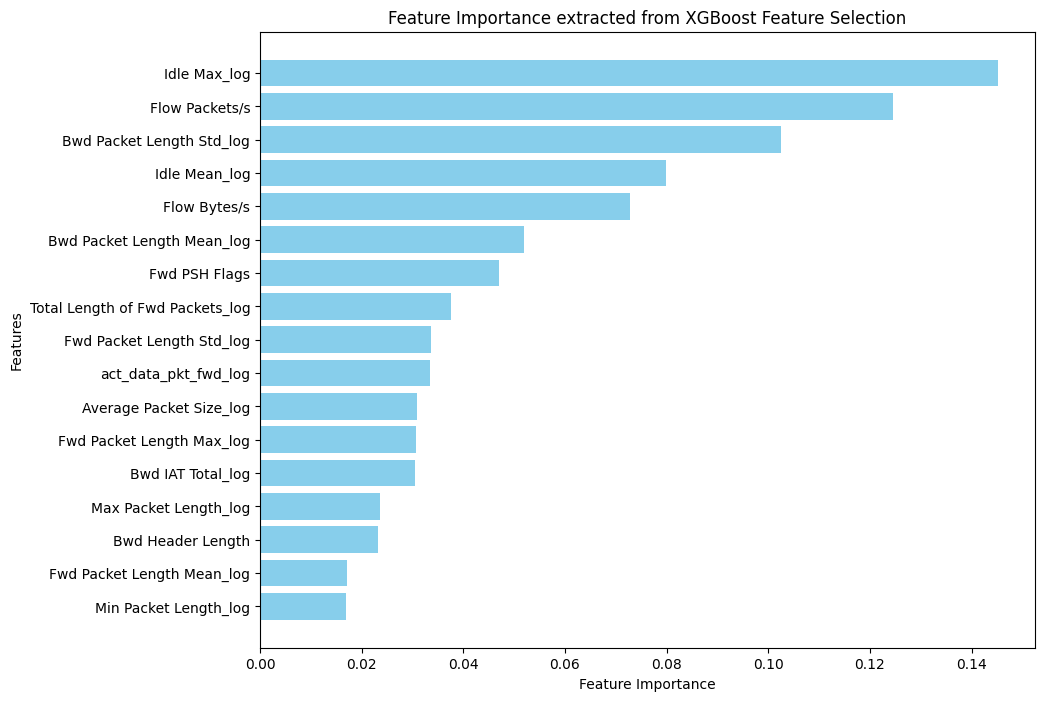

In [43]:
# Plotting Feature Importance

# Extracting feature names and their corresponding significance scores from feature_tuples
feature_names       = [tup[0] for tup in feature_tuples]
significance_scores = [tup[1] for tup in feature_tuples]

# Plotting the horizontal bar plot
plt.figure(figsize=(10, 8))
plt.barh(feature_names, significance_scores, color='skyblue')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance extracted from XGBoost Feature Selection')
# Invert y-axis to display features from top to bottom
plt.gca().invert_yaxis()  
plt.show()


# Feature Engineering

In [44]:
from sklearn.preprocessing import StandardScaler

def create_importance_feature(
    X_train_selected,
    X_val_selected,
    X_test_selected,
    feature_tuples
):

    scaler = StandardScaler()

    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train_selected),
        columns=X_train_selected.columns,
        index=X_train_selected.index
    )

    X_val_scaled = pd.DataFrame(
        scaler.transform(X_val_selected),
        columns=X_val_selected.columns,
        index=X_val_selected.index
    )

    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test_selected),
        columns=X_test_selected.columns,
        index=X_test_selected.index
    )


    feature_names = [x[0] for x in feature_tuples]
    weights = [x[1] for x in feature_tuples]


    X_train_scaled["Combined_Importance_Score"] = (
        X_train_scaled[feature_names] @ weights
    )

    X_val_scaled["Combined_Importance_Score"] = (
        X_val_scaled[feature_names] @ weights
    )

    X_test_scaled["Combined_Importance_Score"] = (
        X_test_scaled[feature_names] @ weights
    )


    return (
        X_train_scaled,
        X_val_scaled,
        X_test_scaled
    )

In [45]:
def create_ids_features(df):

    df = df.copy()
    eps = 1e-9

    # 1- Average bytes per packet
    df["Bytes_Per_Packet"] = (
        df["Flow Bytes/s"] /
        (df["Flow Packets/s"] + eps)
    )

    # 2- Packet size consistency
    df["Packet_Size_Consistency"] = (
        df["Average Packet Size_log"] /
        (df["Max Packet Length_log"] + eps)
    )

    # 3- Idle behavior
    df["Idle_Activity_Ratio"] = (
        df["Idle Max_log"] /
        (df["Idle Mean_log"] + eps)
    )

    # 4- Forward packet profile
    df["Fwd_Packet_Profile"] = (
        df["Fwd Packet Length Max_log"] /
        (df["Fwd Packet Length Mean_log"] + eps)
    )

    # 5- Packet variation ratio
    df["Packet_Variation_Ratio"] = (
        df["Fwd Packet Length Std_log"] /
        (df["Bwd Packet Length Std_log"] + eps)
    )

    # Clean
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(0, inplace=True)

    return df

In [46]:
# Apply IDS Feature Engineering
X_train_selected = create_ids_features(X_train_selected.copy())
X_val_selected   = create_ids_features(X_val_selected.copy())
X_test_selected  = create_ids_features(X_test_selected.copy())

In [47]:
X_train_selected

,Idle Max_log,Flow Packets/s,Bwd Packet Length Std_log,Idle Mean_log,Flow Bytes/s,Bwd Packet Length Mean_log,Fwd PSH Flags,Total Length of Fwd Packets_log,Fwd Packet Length Std_log,act_data_pkt_fwd_log,...,Bwd IAT Total_log,Max Packet Length_log,Bwd Header Length,Fwd Packet Length Mean_log,Min Packet Length_log,Bytes_Per_Packet,Packet_Size_Consistency,Idle_Activity_Ratio,Fwd_Packet_Profile,Packet_Variation_Ratio
1175743,0.000000,52631.578125,0.000000,0.000000,3.157895e+05,1.945910,0,1.945910,0.000000,0.000000,...,0.000000,1.945910,20,1.945910,1.945910,6.000000,1.183295,0.0,1.000000,0.000000e+00
1695078,15.467493,2.822442,6.520944,15.467493,7.340113e+02,6.438285,0,6.030685,4.335443,1.386294,...,12.594419,7.286876,124,3.749504,0.000000,260.062469,0.763669,1.0,1.389380,6.648490e-01
338021,0.000000,35087.718750,0.000000,0.000000,1.403509e+05,1.945910,0,1.098612,0.000000,0.000000,...,0.000000,1.945910,20,1.098612,1.098612,4.000000,0.920782,0.0,1.000000,0.000000e+00
580025,0.000000,165.562912,0.000000,0.000000,2.582781e+04,5.652489,0,4.043051,0.000000,0.693147,...,3.871201,5.652489,40,3.367296,3.367296,156.000000,0.902234,0.0,1.000000,0.000000e+00
1747552,0.000000,51.371624,0.000000,0.000000,3.030926e+03,4.219508,0,3.951244,0.000000,0.000000,...,0.000000,4.219508,20,3.951244,3.951244,59.000000,1.054274,0.0,1.000000,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1941946,0.000000,1.510856,6.178981,0.000000,2.647776e+02,5.487904,0,6.086775,5.395898,0.693147,...,15.457012,6.871091,88,4.707275,0.000000,175.250015,0.752705,0.0,1.293057,8.732666e-01
1835488,0.000000,129.865921,0.000000,0.000000,1.038927e+04,4.744932,0,4.532599,0.000000,0.693147,...,3.891820,4.744932,40,3.850147,3.850148,80.000000,0.954115,0.0,1.000000,0.000000e+00
2302621,18.577685,0.042621,0.000000,18.577684,1.534361e-01,0.000000,0,2.944439,1.386294,1.098612,...,0.000000,1.945910,32,1.704748,0.000000,3.600000,0.903360,1.0,1.141465,1.386294e+09
1306996,0.000000,666666.687500,0.000000,0.000000,1.230000e+07,0.000000,1,3.637586,2.927329,0.693147,...,0.000000,3.465736,0,2.970414,1.945910,18.449999,1.025857,0.0,1.166752,2.927329e+09


# Secondary Evaluation

In [48]:
# Secondary Feature Selection after Feature Engineering

# Combine selected features with generated features
selected_data = [
    X_train_selected,
    X_val_selected,
    X_test_selected,
    y_train,
    y_val,
    y_test
]


# Run Feature Selection again
X_train_final, X_val_final, X_test_final, feature_tuples_final = (
    select_features_by_threshold(
        selected_data,
        threshold=0.01,
        printing=True
    )
)


# Final dataset
final_data = [
    X_train_final,
    X_val_final,
    X_test_final,
    y_train,
    y_val,
    y_test
]


print("\nSecondary Feature Selection completed")
print("Final Features:", X_train_final.shape[1])

[INFO] Using 300,000 samples for Feature Selection
Selected Features : 17 / 22
                        Feature  Importance
                  Idle Mean_log   22.540001
                   Idle Max_log   15.960000
      Bwd Packet Length Std_log   13.110000
     Bwd Packet Length Mean_log    6.360000
                   Flow Bytes/s    5.780000
Total Length of Fwd Packets_log    5.560000
      Fwd Packet Length Max_log    5.520000
           act_data_pkt_fwd_log    5.000000
        Average Packet Size_log    4.240000
      Fwd Packet Length Std_log    2.350000
          Max Packet Length_log    2.350000
         Packet_Variation_Ratio    1.970000
                 Flow Packets/s    1.960000
        Packet_Size_Consistency    1.430000
            Idle_Activity_Ratio    1.290000
          Min Packet Length_log    1.070000
              Bwd Header Length    1.040000

Secondary Feature Selection completed
Final Features: 17


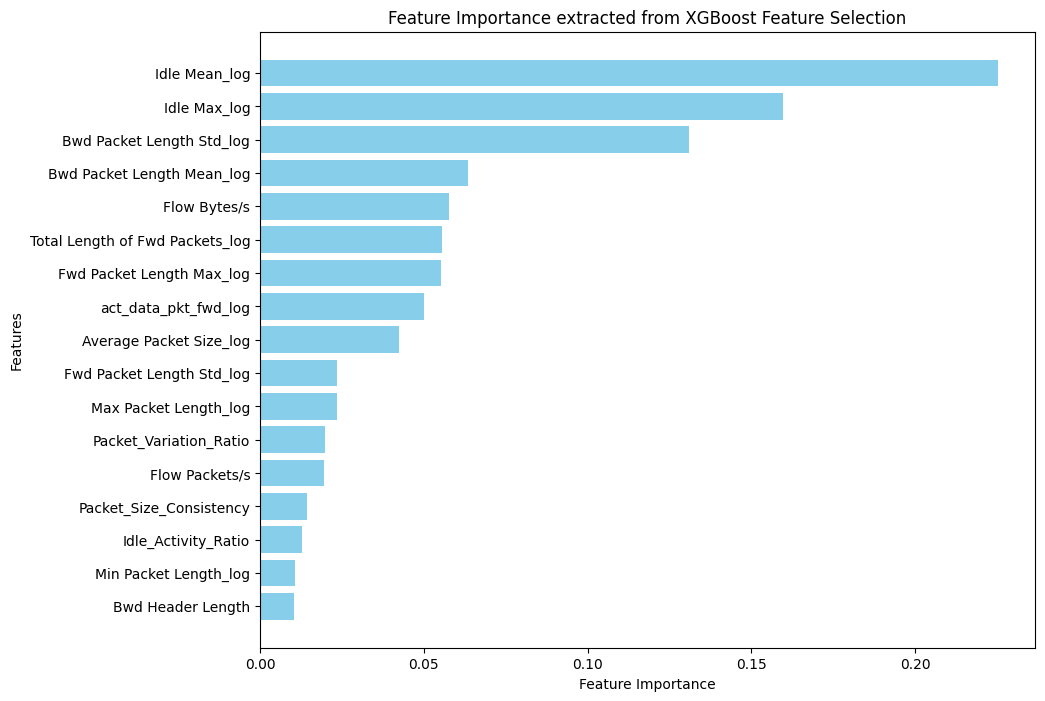

In [49]:
## Plotting Feature Importance

# Extracting feature names and their corresponding significance scores from feature_tuples_final
feature_names       = [tup[0] for tup in feature_tuples_final]
significance_scores = [tup[1] for tup in feature_tuples_final]

# Plotting the horizontal bar plot
plt.figure(figsize=(10, 8))
plt.barh(feature_names, significance_scores, color='skyblue')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance extracted from XGBoost Feature Selection')
# Invert y-axis to display features from top to bottom
plt.gca().invert_yaxis()  
plt.show()

# Scaling

In [50]:
# function z_scale
def z_scale(X_train_selected, X_val_selected, X_test_selected):

    scaler = StandardScaler()

    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train_selected),
        columns=X_train_selected.columns,
        index=X_train_selected.index
    )

    X_val_scaled = pd.DataFrame(
        scaler.transform(X_val_selected),
        columns=X_val_selected.columns,
        index=X_val_selected.index
    )

    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test_selected),
        columns=X_test_selected.columns,
        index=X_test_selected.index
    )

    return X_train_scaled, X_val_scaled, X_test_scaled

In [51]:
# Apply Z-Scaling

X_train_z, X_val_z, X_test_z = z_scale(
    X_train_final,
    X_val_final,
    X_test_final
)

# Store scaled data
scaled_data = [
    X_train_z,
    X_val_z,
    X_test_z,
    y_train,
    y_val,
    y_test
]

print("Scaling completed")
print("Train:", X_train_z.shape)
print("Validation:", X_val_z.shape)
print("Test:", X_test_z.shape)

Scaling completed
Train: (1873638, 17)
Validation: (249818, 17)
Test: (374729, 17)


In [52]:
print(np.unique(y_train))
print(y_train.value_counts())

[0 1 2 3 4 5 6 7]
0    1554332
4     145309
3      96010
5      68021
2       6863
7       1607
1       1461
6         35
Name: count, dtype: int64


In [53]:
print(label_encoder.classes_)

['BENIGN' 'Bot' 'Brute Force' 'DDoS' 'DoS' 'PortScan' 'Rare Attack'
 'Web Attack']


In [54]:
y_train_encoded = y_train
y_val_encoded = y_val
y_test_encoded = y_test

In [55]:
for i, label in enumerate(label_encoder.classes_):
    print(i, "->", label)

0 -> BENIGN
1 -> Bot
2 -> Brute Force
3 -> DDoS
4 -> DoS
5 -> PortScan
6 -> Rare Attack
7 -> Web Attack


In [56]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    sampling_strategy={
        1: 5000,     # Bot
        2: 20000,    # Brute Force
        6: 1000,     # Rare Attack
        7: 5000      # Web Attack
    },
    random_state=42,
    k_neighbors=5
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_z,
    y_train_encoded
)

In [57]:
print(
    pd.Series(y_train_smote).value_counts().sort_index()
)

0    1554332
1       5000
2      20000
3      96010
4     145309
5      68021
6       1000
7       5000
Name: count, dtype: int64


## Encoding

In [58]:
import joblib

In [59]:
scaler = StandardScaler()
scaler.fit(X_train)


,copy,True
,with_mean,True
,with_std,True


In [63]:
import joblib

# Save training data
joblib.dump(X_train_z, "X_train_z.pkl")
joblib.dump(y_train_encoded, "y_train_encoded.pkl")

# Save training data after SMOTE
joblib.dump(X_train_smote, "X_train_smote.pkl")
joblib.dump(y_train_smote, "y_train_smote.pkl")

# Save validation data
joblib.dump(X_val_z, "X_val_z.pkl")
joblib.dump(y_val_encoded, "y_val_encoded.pkl")

# Save test data
joblib.dump(X_test, "X_test.pkl")
joblib.dump(X_test_selected, "X_test_selected.pkl")
joblib.dump(X_test_z, "X_test_z.pkl")
joblib.dump(y_test_encoded, "y_test_encoded.pkl")

# Save preprocessing objects
joblib.dump(label_encoder, "models/label_encoder.pkl")
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(scaler, "artifacts/scaler.pkl")


# Save feature names
joblib.dump(feature_names, "models/feature_names.pkl")

print("All files saved successfully.")

All files saved successfully.
